# Task 1-v2 - Image Segmentation
## Roland Gulbinovič - 2416108

## Notebook Prep

In [ ]:
!pip -q install fiftyone

In [ ]:
!pip -q install albumentations

In [ ]:
!pip -q install segmentation_models_pytorch

In [4]:
import os
from google.colab import drive

import numpy as np
from PIL import Image

import albumentations as A

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

import fiftyone as fo
import fiftyone.zoo as foz
import segmentation_models_pytorch as smp

from glob import glob
from matplotlib import pyplot as plt

from tqdm import tqdm

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.6' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [7]:
# drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# !cp -r /content/drive/MyDrive/dataset2 /content/

In [9]:
fo.config.dataset_zoo_dir = "/content/dataset2"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Dataset preperation

Downloading dataset from fiftyone.

In [ ]:
# dataset = fo.zoo.load_zoo_dataset(
#               "open-images-v7",
#               split= "test",
#               label_types=["segmentations"],
#               classes=["Car", "Motorcycle", "Bus"],
#               max_samples=500
#           )

In [ ]:
# dataset = fo.zoo.load_zoo_dataset(
#     "open-images-v7",
#     split="train",
#     label_types=["segmentations"],
#     dataset_dir="/content/drive/MyDrive/dataset/open-images-v7",
#     max_samples=750,
# )

In [ ]:
dataset.compute_metadata()

OpenImages extracts images that contain the masks for all chosen classes. The problem with this is that it downloads ALL masks for those images - including classes that are not needed in my case. In this code we take only needed masks and process them for training.

In [ ]:
import os
import numpy as np
from PIL import Image

output_mask_dir = "G:/dataset2/open-images-v7/test/labels/masks/combined_masks"
os.makedirs(output_mask_dir, exist_ok=True)

image_paths = []
mask_paths = []

label_map = {
    "Car": 1,
    "Motorcycle": 2,
    "Bus": 3,
}

for sample in dataset:
    detections = sample["ground_truth"].detections
    height = sample.metadata.height
    width = sample.metadata.width

    mask = np.zeros((height, width), dtype=np.uint8)

    for det in detections:
        class_id = label_map.get(det.label)
        if class_id is None:
            continue  # skip classes that we don't need

        binary_mask = det.mask.astype(np.uint8)

        x, y, w, h = det.bounding_box
        x1 = round(x * width)
        y1 = round(y * height)
        x2 = round((x + w) * width)
        y2 = round((y + h) * height)

        # Safety check
        if x2 <= x1 or y2 <= y1:
            continue

        resized = Image.fromarray(binary_mask * 255).resize(
            (x2 - x1, y2 - y1), resample=Image.NEAREST
        )
        resized_mask = np.array(resized) > 0

        # Apply the resized mask
        mask_section = mask[y1:y2, x1:x2]
        mask_section[resized_mask] = class_id
        mask[y1:y2, x1:x2] = mask_section

    if np.any(mask):
        filename = os.path.splitext(os.path.basename(sample.filepath))[0]
        mask_filename = filename + ".png"
        mask_path = os.path.join(output_mask_dir, mask_filename)
        Image.fromarray(mask).save(mask_path)

        image_paths.append(sample.filepath)
        mask_paths.append(mask_path)

When we have all our images and their respective masks - we can gather all the paths and we will later use these paths for all other functions

In [ ]:
image_paths_train = sorted(glob("/content/dataset2/open-images-v7/train/data/*.jpg"))
mask_paths_train = sorted(glob("/content/dataset2/open-images-v7/train/labels/masks/combined_masks/*.png"))

In [ ]:
image_paths_train = sorted(image_paths_train, key=lambda x: os.path.basename(x))
mask_paths_train = sorted(mask_paths_train, key=lambda x: os.path.basename(x))

In [ ]:
image_paths_test = sorted(glob("/content/dataset2/open-images-v7/test/data/*.jpg"))
mask_paths_test = sorted(glob("/content/dataset2/open-images-v7/test/labels/masks/combined_masks/*.png"))

In [ ]:
image_paths_test = sorted(image_paths_test, key=lambda x: os.path.basename(x))
mask_paths_test = sorted(mask_paths_test, key=lambda x: os.path.basename(x))

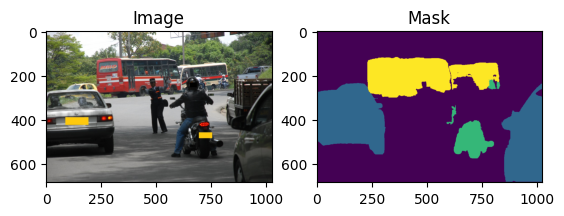

In [ ]:
img = np.array(Image.open(image_paths_train[7222]))
mask = np.array(Image.open(mask_paths_train[7222]))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Mask")

plt.show()

## Functions & Classes

In [10]:
class SegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, size=(256, 256), transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.size = size
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx])

        # Resize
        image = image.resize(self.size, Image.BILINEAR)
        mask = mask.resize(self.size, Image.NEAREST)

        # Convert to numpy
        image = np.array(image).astype(np.float32) / 255.0
        mask = np.array(mask)

        # 🔥 Apply augmentation (if any)
        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # 🔥 FIX the mask after augmentation:
        mask = mask.astype(np.int64)  # Ensure it's integer class labels!

        # Convert to tensor
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).long()

        return image, mask



  # UNet model structure created manually
class UNet(nn.Module):
    def __init__(self, num_classes):
        super(UNet, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, 3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )

        self.enc1 = conv_block(3, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = conv_block(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = conv_block(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat((d4, e4), dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat((d3, e3), dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [123]:
from torch.amp import autocast, GradScaler  # <-- new import!

def train_segmentation_model(
    model,
    dataset,
    device,
    num_epochs=10,
    batch_size=4,
    learning_rate=1e-4,
    num_classes=4,
    weights=None
):
    val_split = 0.1
    val_size = int(val_split * len(dataset))
    train_size = len(dataset) - val_size
    train_set, val_set = torch.utils.data.random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=1)
    val_loader = DataLoader(val_set, batch_size=batch_size, num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=1)

    model = model.to(device)
    weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)
    dice_loss = smp.losses.DiceLoss(mode="multiclass")
    ce_loss = nn.CrossEntropyLoss(weight=weights_tensor)

    def combined_loss(pred, target):
        return dice_loss(pred, target) + ce_loss(pred, target)

    criterion = combined_loss
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scaler = GradScaler()

    best_val_loss = float('inf')  # 🔥 Track best val loss

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, masks in tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{num_epochs}"):
            images = images.to(device)
            masks = masks.to(device)
            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                with autocast(device_type='cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, masks)

                val_loss += loss.item()

                # 🔥 Threshold predictions (optional for evaluation only)
                probs = torch.softmax(outputs, dim=1)
                max_probs, preds = torch.max(probs, dim=1)
                preds[max_probs < 0.7] = 0

        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Train Loss: {avg_loss:.4f}  Val Loss: {avg_val_loss:.4f}")

        # 🔥 Save best model if validation improves
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "best_model.pth")
            print(f"✅ New best model saved with Val Loss: {best_val_loss:.4f}")

    return model


# Get model statistsics
def evaluate_model(model, dataloader, device):
    y_true = []
    y_pred = []

    model.eval()
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            if isinstance(outputs, dict):
                outputs = outputs["out"]

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(masks.cpu().numpy().flatten())
            y_pred.extend(preds.cpu().numpy().flatten())

    print("✅ Evaluation Metrics:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average="macro", zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, average="macro", zero_division=0))
    print("F1 Score:", f1_score(y_true, y_pred, average="macro", zero_division=0))


# Input an image path - predict the mask - return comparison
def predict_and_visualize(image_path, model, device, size=(256, 256), class_colors=None):
    original = Image.open(image_path).convert("RGB")
    resized = original.resize(size)
    image_np = np.array(resized).astype(np.float32) / 255.0
    image_tensor = torch.from_numpy(image_np).permute(2, 0, 1).unsqueeze(0).to(device)  # Shape: (1, 3, H, W)

    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        if isinstance(output, dict):
            output = output["out"]

        prediction = torch.argmax(output.squeeze(), dim=0).cpu().numpy()

    prediction_resized = Image.fromarray(prediction.astype(np.uint8)).resize(original.size, Image.NEAREST)
    prediction_resized = np.array(prediction_resized)

    if class_colors:
        color_mask = np.zeros((*prediction_resized.shape, 3), dtype=np.uint8)
        for class_id, color in class_colors.items():
            color_mask[prediction_resized == class_id] = color
    else:
        color_mask = prediction_resized

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original Image")

    plt.subplot(1, 2, 2)
    plt.imshow(color_mask if class_colors else prediction_resized, cmap="tab10")
    plt.title("Predicted Mask")

    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return prediction_resized

# Since classes are so imbalanced, calculation of class weights is needed
def compute_class_weights(mask_paths, num_classes):
    class_counts = np.zeros(num_classes)

    for mask_path in tqdm(mask_paths):
        mask = np.array(Image.open(mask_path))
        for c in range(num_classes):
            class_counts[c] += np.sum(mask == c)

    class_counts[class_counts == 0] = 1

    weights = 1.0 / class_counts
    weights = weights / weights.sum()  # Normalize to sum to 1
    return weights

## Augmentations
Cars are usually in streets. These are quite difficult images because there's a lot of information (lots of cars, weird backgrounds, houses sometime can look like buses etc..). To get better results and get our model to really adjust to lighting, different angles etc we add Augmentations.

In [48]:
train_transform = A.Compose([
    A.Affine(scale=(0.9, 1.1), translate_percent=(0.05, 0.05), rotate=(-10, 10), p=0.7),

    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.RandomGamma(p=0.3),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),

    A.GaussNoise(p=0.2),
    A.MotionBlur(blur_limit=3, p=0.1),

    A.CoarseDropout(max_holes=8, max_height=64, max_width=64, p=0.4),
])

<ipython-input-48-4de1b5034d69>:12: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=64, max_width=64, p=0.4),


## Class Weights

We compute the class weights.

This is something I noticed is needed, because without Dice Loss and Weights we get a model that always predicts the dominant class (car). Since Motorcycle and Bus images are much more rare in our dataset, the model just always predicts car as it learned that guessing car almost almost is correct.

Adding weights and Dice Loss in our training loop helps fix this.

In [20]:
weights = compute_class_weights(mask_paths_train, num_classes=4)
print("Class weights:", weights)

100%|██████████| 7223/7223 [00:30<00:00, 237.35it/s]

Class weights: [0.01553444 0.08319535 0.48834556 0.41292464]


## Loading Data & Model training

We crate datasets and DataLoaders for training set and testing set.
The Training set contains 750 images. Testing contains 100 new Images.

In [49]:
dataset_train = SegmentationDataset(
    image_paths_train, mask_paths_train, size=(256, 256), transform = train_transform
)

dataset_test = SegmentationDataset(
    image_paths_test, mask_paths_test, size=(256, 256)
)

In [50]:
train_loader = DataLoader(dataset_train, batch_size=8, shuffle=True, num_workers=4, pin_memory=True,
    persistent_workers=True)
test_loader = DataLoader(dataset_test, batch_size=8, shuffle=True, num_workers=4,
    pin_memory=True,
    persistent_workers=True)

### Model created from scratch

In [109]:
model = UNet(num_classes=4).to(device)

In [ ]:
# Import an already trained model (.pth file)
model = UNet(num_classes=4).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/dataset/unet_model.pth", map_location=torch.device('cpu')))
model.to(device)
model.eval()

This is the main training loop.
num_classes is 4 and not 3, because we are also predicting the 'background'

In [51]:
model = train_segmentation_model(
    model=model,
    dataset=dataset_train,
    device=device,
    num_epochs=50,
    batch_size=8,
    learning_rate=1e-4,
    num_classes=4,
    weights = weights
)

Training Epoch 1/50: 100%|██████████| 813/813 [01:45<00:00,  7.68it/s]


Epoch [1/50]
Train Loss: 1.7988  Val Loss: 1.5842
✅ New best model saved with Val Loss: 1.5842


Training Epoch 2/50: 100%|██████████| 813/813 [01:45<00:00,  7.72it/s]


Epoch [2/50]
Train Loss: 1.6015  Val Loss: 1.5318
✅ New best model saved with Val Loss: 1.5318


Training Epoch 3/50: 100%|██████████| 813/813 [01:45<00:00,  7.74it/s]


...

Epoch [48/50]
Train Loss: 0.6983  Val Loss: 0.8695


Training Epoch 49/50: 100%|██████████| 813/813 [01:45<00:00,  7.69it/s]


Epoch [49/50]
Train Loss: 0.6830  Val Loss: 0.8643


Training Epoch 50/50: 100%|██████████| 813/813 [01:45<00:00,  7.68it/s]


Epoch [50/50]
Train Loss: 0.6623  Val Loss: 0.8559


In [90]:
#torch.save(model.state_dict(), "/content/drive/MyDrive/dataset2/unet_model1.pth")

Calling `evaluate_model()` to get the Accuracy, Precision, Recall, F1 Score.

The overall accuracy can be quite misleading, because a model could be good at predicting the background really well.

In [52]:
evaluate_model(model, test_loader, device)

✅ Evaluation Metrics:
Accuracy: 0.7366123962402343
Precision: 0.6777419041166799
Recall: 0.7731335669071189
F1 Score: 0.6848160875866209


### Model with Pre-trained Encoder

We can also try using an already pre-built UNet structure. segmentation_models_pytorch has an UNet model with a pre-built encoder. This means that the model will most likely be much better at predicting the shapes and the edges of images. We can expect much better results.

In [67]:
import segmentation_models_pytorch as smp

In [68]:
model_smp = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=4
)
model_smp = model_smp.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [87]:
model_smp = train_segmentation_model(
    model=model_smp,
    dataset=dataset_train,
    device=device,
    num_epochs=15,
    batch_size=8,
    learning_rate=1e-4,
    num_classes=4,
    weights = weights
)

Training Epoch 1/15: 100%|██████████| 813/813 [01:09<00:00, 11.64it/s]


Epoch [1/15]
Train Loss: 0.4482  Val Loss: 0.3483
✅ New best model saved with Val Loss: 0.3483


Training Epoch 2/15: 100%|██████████| 813/813 [01:09<00:00, 11.74it/s]


Epoch [2/15]
Train Loss: 0.4307  Val Loss: 0.3983


Training Epoch 3/15: 100%|██████████| 813/813 [01:08<00:00, 11.88it/s]


...

Epoch [13/15]
Train Loss: 0.3224  Val Loss: 0.4218


Training Epoch 14/15: 100%|██████████| 813/813 [01:08<00:00, 11.79it/s]


Epoch [14/15]
Train Loss: 0.3672  Val Loss: 0.4542


Training Epoch 15/15: 100%|██████████| 813/813 [01:08<00:00, 11.86it/s]


Epoch [15/15]
Train Loss: 0.3368  Val Loss: 0.4480


In [70]:
evaluate_model(model_smp, test_loader, device)

✅ Evaluation Metrics:
Accuracy: 0.7603949279785156
Precision: 0.666237545647345
Recall: 0.8561333991623022
F1 Score: 0.7190095672589538


## Load models and do predictions

In [ ]:
# Model from scratch
model.load_state_dict(torch.load("/content/drive/MyDrive/dataset2/unet_model.pth"))

In [ ]:
# Model pre-trained encoder
model_smp.load_state_dict(torch.load("/content/drive/MyDrive/dataset2/best_model.pth"))

In [ ]:
class_colors = {
    0: (0, 0, 0),         # background = black
    1: (255, 0, 0),       # car = red
    2: (0, 255, 0),       # motorcycle = green
    3: (0, 0, 255),       # bus = blue
}

In [106]:
path = "/content/image5.jpg"

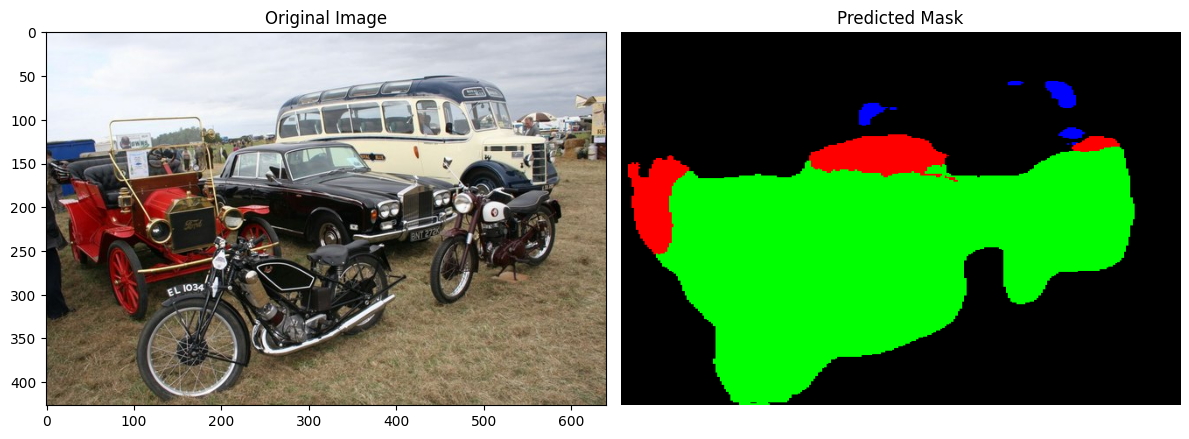

In [107]:
prediction = predict_and_visualize(path, model_smp, device, class_colors=class_colors)

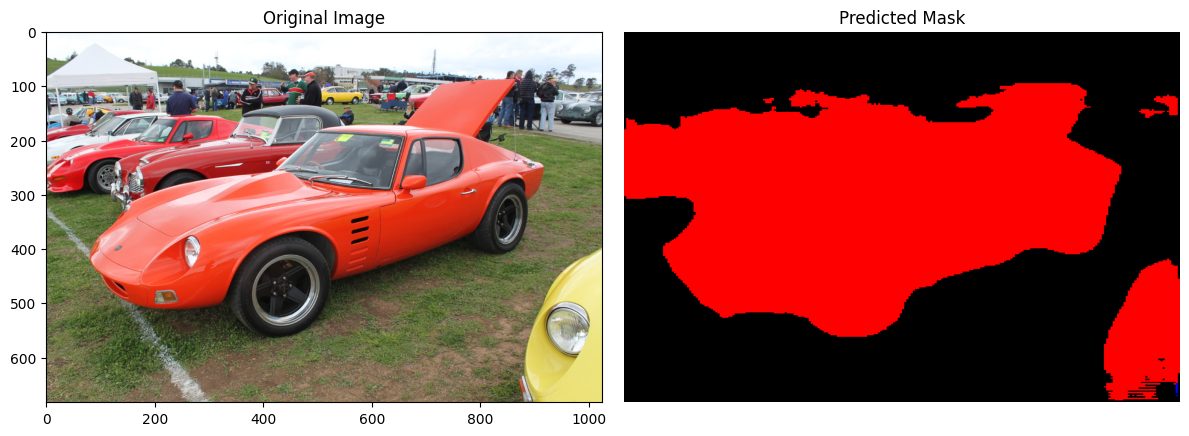

In [126]:
prediction = predict_and_visualize(image_paths_test[4], model, device, class_colors=class_colors)

In [127]:
prediction

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [128]:
x, y = 123, 123
predicted_class = prediction[y, x]
print(f"Predicted class at pixel (123,123):", predicted_class)

Predicted class at pixel (123,123): 0


In [131]:
image_tensor, _ = dataset_train[0]
image_tensor = image_tensor.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(image_tensor)
    if isinstance(output, dict):
        output = output["out"]

    logits = output.squeeze(0)

# Pick your pixel
x, y = 123, 123
pixel_logits = logits[:, y, x]
pixel_probs = torch.softmax(pixel_logits, dim=0)

max_prob = torch.max(pixel_probs)
pred_class = torch.argmax(pixel_probs).item()

print(f"Pixel logits: {pixel_logits.cpu().numpy()}")
print(f"Pixel probs: {pixel_probs.cpu().numpy()}")
print(f"Predicted class: {pred_class}")

Pixel logits: [ 6.120096  -4.9829097 -5.7322006 -1.8236593]
Pixel probs: [9.99623060e-01 1.50612805e-05 7.11949497e-06 3.54737451e-04]
Predicted class: 0
